In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [95]:
model_df=pd.read_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\data\processed\hhs_feature.csv")

In [96]:
model_df["Date"] = pd.to_datetime(
    model_df["Date"]
)

In [97]:
model_df = model_df.sort_values(
    "Date"
).reset_index(drop=True)

In [98]:
target = "Children in HHS Care"

In [99]:
y = model_df[
    ["Date", target]
].copy()

In [100]:
print(y.head())
print(y.tail())

        Date  Children in HHS Care
0 2023-01-12                  6566
1 2023-01-22                  7122
2 2023-01-23                  7280
3 2023-01-24                  7433
4 2023-01-25                  7538
          Date  Children in HHS Care
715 2025-12-15                  2470
716 2025-12-16                  2468
717 2025-12-17                  2481
718 2025-12-18                  2472
719 2025-12-21                  2484


In [101]:
split_index = int(len(y) * 0.80)

train = y.iloc[:split_index].copy()
test = y.iloc[split_index:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 576
Testing observations: 144


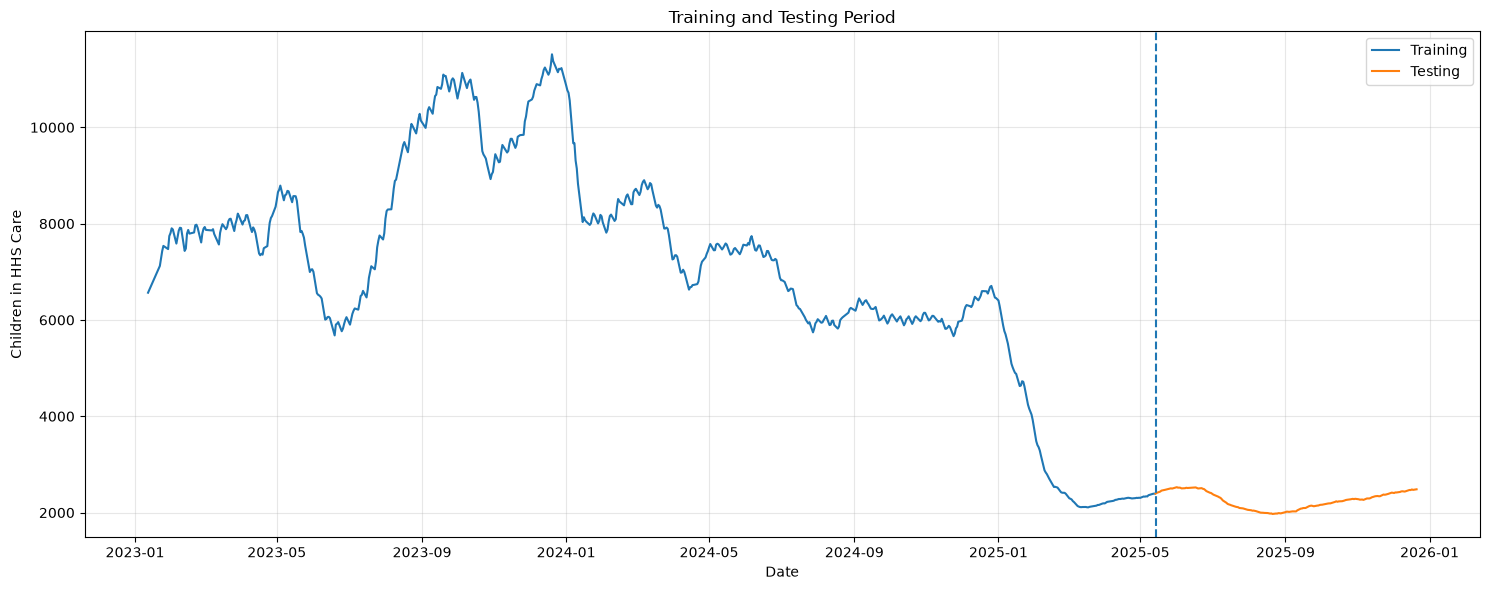

In [102]:
plt.figure(figsize=(15, 6))

plt.plot(
    train["Date"],
    train[target],
    label="Training"
)

plt.plot(
    test["Date"],
    test[target],
    label="Testing"
)

plt.axvline(
    test["Date"].iloc[0],
    linestyle="--"
)

plt.title("Training and Testing Period")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# Baseline Model
## 1 — Naïve Forecast

In [103]:
naive_predictions = np.repeat(
    train[target].iloc[-1],
    len(test)
)

In [104]:
naive_mae = mean_absolute_error(
    test[target],
    naive_predictions
)

print("Naïve MAE:", naive_mae)

Naïve MAE: 186.50694444444446


In [105]:
naive_rmse = np.sqrt(
    mean_squared_error(
        test[target],
        naive_predictions
    )
)

print("Naïve RMSE:", naive_rmse)

Naïve RMSE: 227.22854684216065


## 2 — Moving Average

In [106]:
window = 7

moving_average_prediction = np.repeat(
    train[target].tail(window).mean(),
    len(test)
)

In [107]:
ma_mae = mean_absolute_error(
    test[target],
    moving_average_prediction
)

ma_rmse = np.sqrt(
    mean_squared_error(
        test[target],
        moving_average_prediction
    )
)

print("Moving Average MAE:", ma_mae)
print("Moving Average RMSE:", ma_rmse)

Moving Average MAE: 174.73313492063497
Moving Average RMSE: 208.66256400685262


In [108]:
baseline_results = pd.DataFrame({
    "Model": [
        "Naive",
        "7-Day Moving Average"
    ],
    "MAE": [
        naive_mae,
        ma_mae
    ],
    "RMSE": [
        naive_rmse,
        ma_rmse
    ]
})

baseline_results

,Model,MAE,RMSE
0,Naive,186.506944,227.228547
1,7-Day Moving Average,174.733135,208.662564


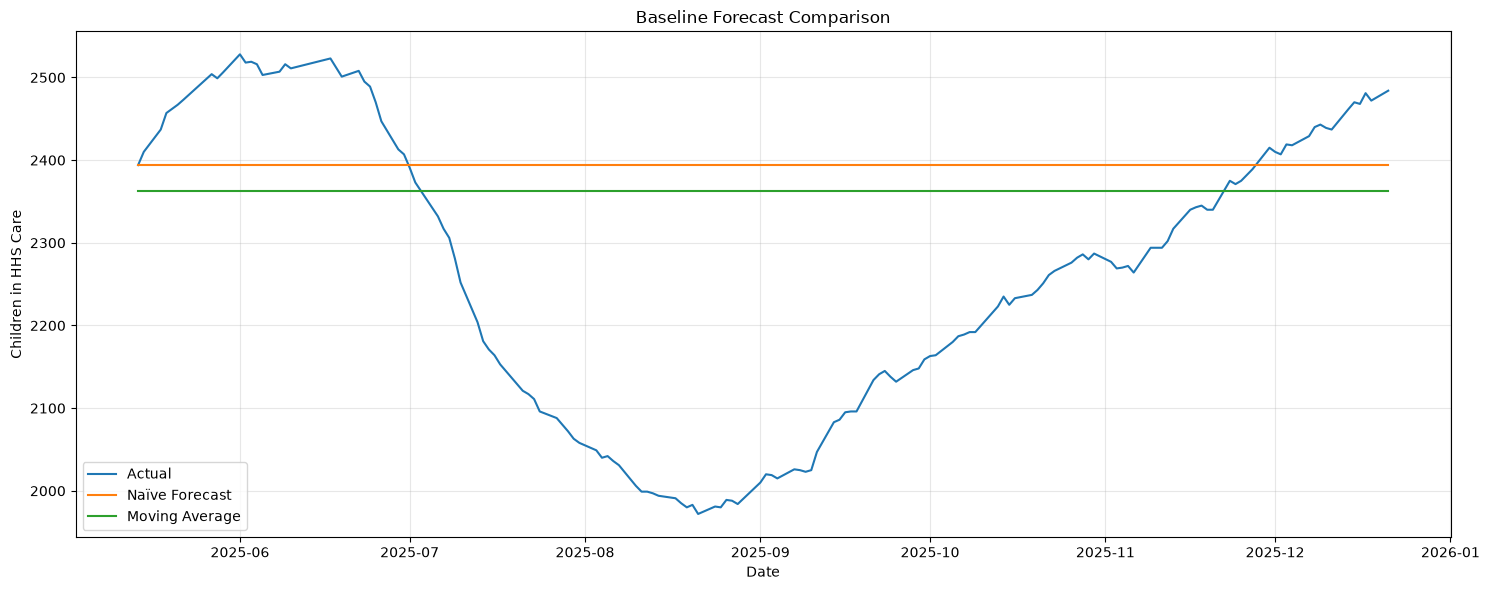

In [109]:
plt.figure(figsize=(15, 6))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    naive_predictions,
    label="Naïve Forecast"
)

plt.plot(
    test["Date"],
    moving_average_prediction,
    label="Moving Average"
)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Exponential Smoothing

In [110]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [111]:
train_values = train[target].values

exp_model = ExponentialSmoothing(
    train_values,
    trend="add",
    seasonal=None
)

exp_fit = exp_model.fit(
    optimized=True
)

In [112]:
exp_predictions = exp_fit.forecast(
    len(test)
)

In [113]:
exp_mae = mean_absolute_error(
    test[target],
    exp_predictions
)

exp_rmse = np.sqrt(
    mean_squared_error(
        test[target],
        exp_predictions
    )
)

print("Exponential Smoothing MAE:", exp_mae)
print("Exponential Smoothing RMSE:", exp_rmse)

Exponential Smoothing MAE: 703.5138031953934
Exponential Smoothing RMSE: 786.7896260372617


In [114]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing"
    ],
    "MAE": [
        naive_mae,
        ma_mae,
        exp_mae
    ],
    "RMSE": [
        naive_rmse,
        ma_rmse,
        exp_rmse
    ]
})

results

,Model,MAE,RMSE
0,Naive,186.506944,227.228547
1,7-Day Moving Average,174.733135,208.662564
2,Exponential Smoothing,703.513803,786.789626


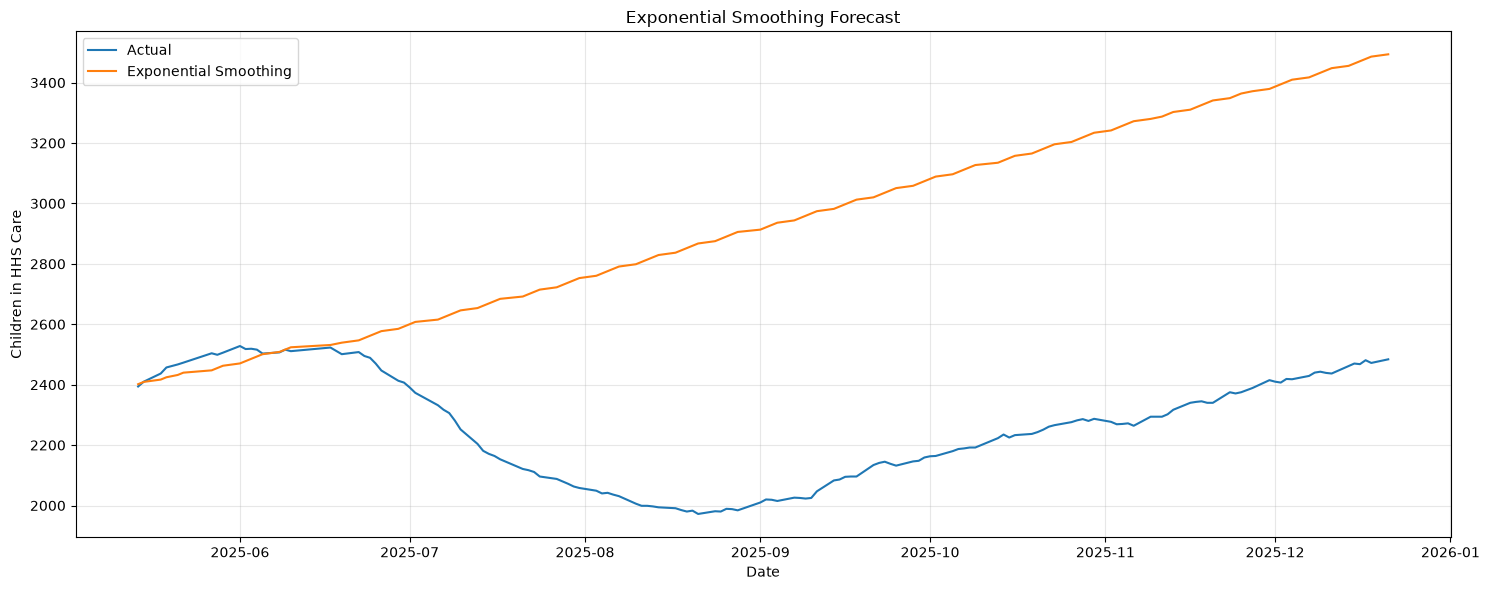

In [115]:
plt.figure(figsize=(15, 6))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    exp_predictions,
    label="Exponential Smoothing"
)

plt.title("Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Exponential Smoothing Result

Exponential Smoothing produced an MAE of approximately 703.51 and an RMSE of approximately 786.79, substantially worse than both the Naïve and 7-day Moving Average baselines.

The poor performance may be related to the irregular reporting frequency of the source dataset. The data contains systematic missing calendar dates, particularly Fridays and Saturdays. Therefore, standard regular-frequency exponential smoothing is not considered an appropriate final forecasting model for this dataset.

The model is retained as a benchmark but excluded from final model selection.

## ARIMA

In [116]:
from statsmodels.tsa.arima.model import ARIMA

In [117]:
arima_model = ARIMA(
    train[target],
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

In [118]:
arima_predictions = arima_fit.forecast(
    steps=len(test)
)

In [119]:
arima_mae = mean_absolute_error(
    test[target],
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test[target],
        arima_predictions
    )
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 186.63942655311791
ARIMA RMSE: 227.42381125793565


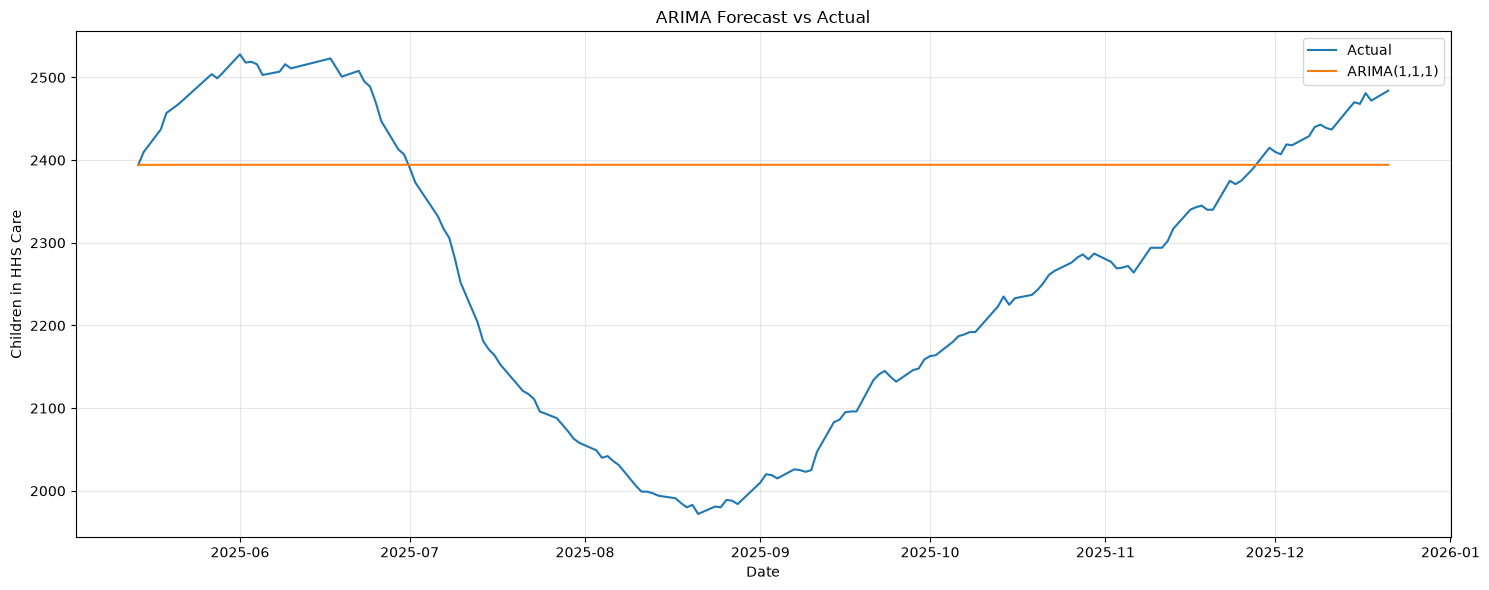

In [120]:
plt.figure(figsize=(15, 6))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    arima_predictions,
    label="ARIMA(1,1,1)"
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [121]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing",
        "ARIMA(1,1,1)"
    ],
    "MAE": [
        naive_mae,
        ma_mae,
        exp_mae,
        arima_mae
    ],
    "RMSE": [
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE
1,7-Day Moving Average,174.733135,208.662564
0,Naive,186.506944,227.228547
3,"ARIMA(1,1,1)",186.639427,227.423811
2,Exponential Smoothing,703.513803,786.789626


## 4. Machine Learning Models
### 4.1 Random Forest Regressor

In [122]:
from sklearn.ensemble import RandomForestRegressor

In [123]:
features = [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "Net_Pressure",
    "Discharge_to_Transfer_Ratio",
    "hhs_lag_1",
    "hhs_lag_7",
    "hhs_lag_14",
    "hhs_lag_28",
    "transfer_lag_1",
    "transfer_lag_7",
    "transfer_lag_14",
    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",
    "hhs_rolling_mean_7d",
    "hhs_rolling_mean_14d",
    "hhs_rolling_std_7d",
    "hhs_rolling_std_14d"
]

In [124]:
ml_df = model_df[
    ["Date", target] + features
].dropna().copy()

In [125]:
print(ml_df.shape)
print(ml_df.isna().sum().sum())

(490, 25)
0


In [126]:
ml_split = int(len(ml_df) * 0.80)

ml_train = ml_df.iloc[:ml_split].copy()
ml_test = ml_df.iloc[ml_split:].copy()

print("ML training observations:", len(ml_train))
print("ML testing observations:", len(ml_test))

ML training observations: 392
ML testing observations: 98


In [127]:
X_train = ml_train[features]
y_train = ml_train[target]

X_test = ml_test[features]
y_test = ml_test[target]

In [128]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [129]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [130]:
rf_predictions = rf_model.predict(X_test)

In [131]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 72.61409812532511


In [132]:
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 93.42876823508445


In [133]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing",
        "ARIMA(1,1,1)",
        "Random Forest"
    ],
    "MAE": [
        naive_mae,
        ma_mae,
        exp_mae,
        arima_mae,
        rf_mae
    ],
    "RMSE": [
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse,
        rf_rmse
    ]
})

results = results.sort_values("MAE")

results

,Model,MAE,RMSE
4,Random Forest,72.614098,93.428768
1,7-Day Moving Average,174.733135,208.662564
0,Naive,186.506944,227.228547
3,"ARIMA(1,1,1)",186.639427,227.423811
2,Exponential Smoothing,703.513803,786.789626


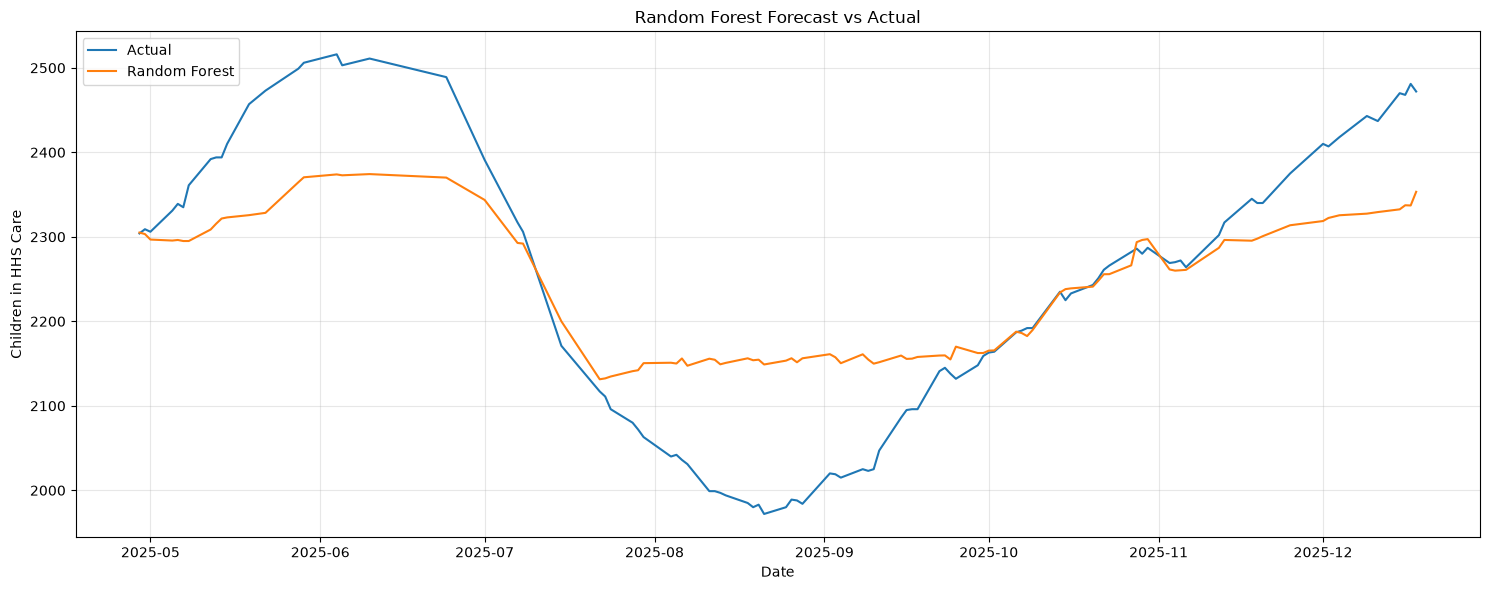

In [134]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_test["Date"],
    y_test,
    label="Actual"
)

plt.plot(
    ml_test["Date"],
    rf_predictions,
    label="Random Forest"
)

plt.title("Random Forest Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [135]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                        Feature  Importance
9                     hhs_lag_1    0.643000
19          hhs_rolling_mean_7d    0.152738
20         hhs_rolling_mean_14d    0.099044
10                    hhs_lag_7    0.060444
11                   hhs_lag_14    0.030824
4                          year    0.004161
13               transfer_lag_1    0.002363
14               transfer_lag_7    0.001672
12                   hhs_lag_28    0.001586
5                  week_of_year    0.001123
16              discharge_lag_1    0.000878
2                         month    0.000657
15              transfer_lag_14    0.000384
17              discharge_lag_7    0.000291
18             discharge_lag_14    0.000195
7                  Net_Pressure    0.000181
22          hhs_rolling_std_14d    0.000172
1                  day_of_month    0.000085
21           hhs_rolling_std_7d    0.000078
8   Discharge_to_Transfer_Ratio    0.000071
3                       quarter    0.000040
0                   day_of_week 

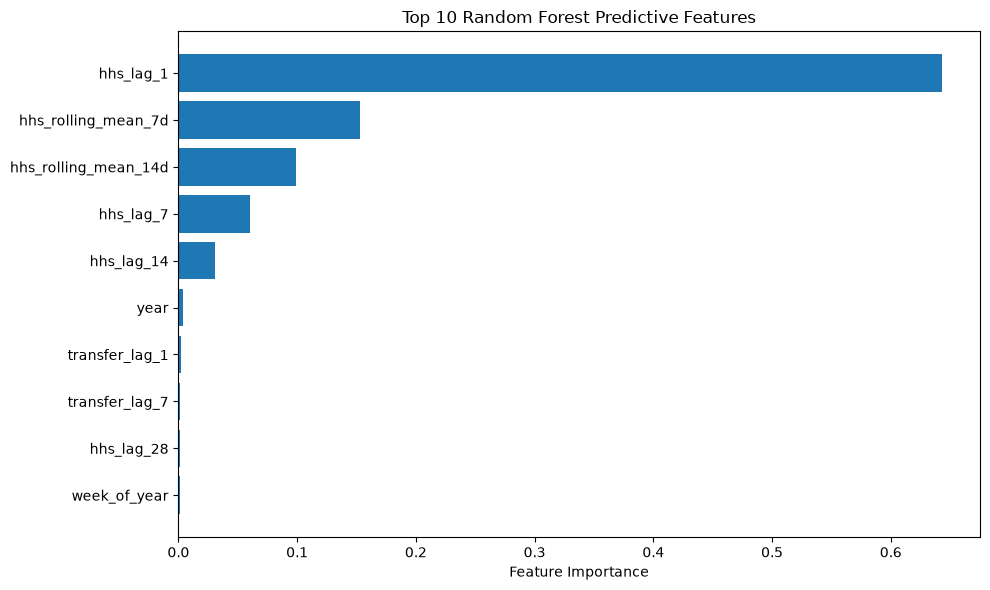

In [136]:
top_features = importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Random Forest Predictive Features")
plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()

## 4.2 Gradient Boosting Regressor

In [137]:
from sklearn.ensemble import GradientBoostingRegressor

In [138]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    loss="squared_error",
    random_state=42
)

In [139]:
gb_model.fit(
    X_train,
    y_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [140]:
gb_predictions = gb_model.predict(
    X_test
)

In [141]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 70.82673437887598
Gradient Boosting RMSE: 91.84660523015046


In [142]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing",
        "ARIMA(1,1,1)",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        naive_mae,
        ma_mae,
        exp_mae,
        arima_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results = results.sort_values("MAE")

results

,Model,MAE,RMSE
5,Gradient Boosting,70.826734,91.846605
4,Random Forest,72.614098,93.428768
1,7-Day Moving Average,174.733135,208.662564
0,Naive,186.506944,227.228547
3,"ARIMA(1,1,1)",186.639427,227.423811
2,Exponential Smoothing,703.513803,786.789626


In [143]:
def calculate_mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mask = actual != 0

    return (
        np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        ) * 100
    )
   
    

In [144]:
rf_mape = calculate_mape(
    y_test,
    rf_predictions
)

gb_mape = calculate_mape(
    y_test,
    gb_predictions
)

print("Random Forest MAPE:", rf_mape)
print("Gradient Boosting MAPE:", gb_mape)

Random Forest MAPE: 3.333074058790971
Gradient Boosting MAPE: 3.2126456387942746


## 5. Forecast-Safe Feature Engineering

In [145]:
forecast_features = [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",

    "hhs_lag_1",
    "hhs_lag_7",
    "hhs_lag_14",
    "hhs_lag_28",

    "transfer_lag_1",
    "transfer_lag_7",
    "transfer_lag_14",

    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",

    "hhs_rolling_mean_7d",
    "hhs_rolling_mean_14d",
    "hhs_rolling_std_7d",
    "hhs_rolling_std_14d"
]

In [146]:
forecast_df = model_df[
    ["Date", target] + forecast_features
].dropna().copy()

In [147]:
print(forecast_df.shape)
print(forecast_df.isna().sum().sum())

(491, 23)
0


In [148]:
forecast_split = int(len(forecast_df) * 0.80)

forecast_train = forecast_df.iloc[:forecast_split].copy()
forecast_test = forecast_df.iloc[forecast_split:].copy()

print("Training:", len(forecast_train))
print("Testing:", len(forecast_test))

Training: 392
Testing: 99


In [149]:
X_train_fs = forecast_train[forecast_features]
y_train_fs = forecast_train[target]

X_test_fs = forecast_test[forecast_features]
y_test_fs = forecast_test[target]

In [150]:
rf_fs = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_fs.fit(
    X_train_fs,
    y_train_fs
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [151]:
rf_fs_predictions = rf_fs.predict(
    X_test_fs
)

In [152]:
rf_fs_mae = mean_absolute_error(
    y_test_fs,
    rf_fs_predictions
)

rf_fs_rmse = np.sqrt(
    mean_squared_error(
        y_test_fs,
        rf_fs_predictions
    )
)

rf_fs_mape = calculate_mape(
    y_test_fs,
    rf_fs_predictions
)

print("Forecast-Safe Random Forest")
print("MAE :", rf_fs_mae)
print("RMSE:", rf_fs_rmse)
print("MAPE:", rf_fs_mape)

Forecast-Safe Random Forest
MAE : 72.47109876057318
RMSE: 93.49535531472394
MAPE: 3.3168789878868066


In [153]:
gb_fs = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    loss="squared_error",
    random_state=42
)

gb_fs.fit(
    X_train_fs,
    y_train_fs
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [154]:
gb_fs_predictions = gb_fs.predict(
    X_test_fs
)

In [155]:
gb_fs_mae = mean_absolute_error(
    y_test_fs,
    gb_fs_predictions
)

gb_fs_rmse = np.sqrt(
    mean_squared_error(
        y_test_fs,
        gb_fs_predictions
    )
)

gb_fs_mape = calculate_mape(
    y_test_fs,
    gb_fs_predictions
)

print("Forecast-Safe Gradient Boosting")
print("MAE :", gb_fs_mae)
print("RMSE:", gb_fs_rmse)
print("MAPE:", gb_fs_mape)

Forecast-Safe Gradient Boosting
MAE : 69.01054367061867
RMSE: 88.7575365835688
MAPE: 3.1070219024992336


In [156]:
final_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "7-Day Moving Average",
        "ARIMA(1,1,1)",
        "Random Forest - All Features",
        "Gradient Boosting - All Features",
        "Random Forest - Forecast Safe",
        "Gradient Boosting - Forecast Safe"
    ],

    "MAE": [
        naive_mae,
        ma_mae,
        arima_mae,
        rf_mae,
        gb_mae,
        rf_fs_mae,
        gb_fs_mae
    ],

    "RMSE": [
        naive_rmse,
        ma_rmse,
        arima_rmse,
        rf_rmse,
        gb_rmse,
        rf_fs_rmse,
        gb_fs_rmse
    ],

    "MAPE": [
        calculate_mape(test[target], naive_predictions),
        calculate_mape(test[target], moving_average_prediction),
        calculate_mape(test[target], arima_predictions),
        rf_mape,
        gb_mape,
        rf_fs_mape,
        gb_fs_mape
    ]
})

final_comparison = final_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

final_comparison

,Model,MAE,RMSE,MAPE
0,Gradient Boosting - Forecast Safe,69.010544,88.757537,3.107022
1,Gradient Boosting - All Features,70.826734,91.846605,3.212646
2,Random Forest - Forecast Safe,72.471099,93.495355,3.316879
3,Random Forest - All Features,72.614098,93.428768,3.333074
4,7-Day Moving Average,174.733135,208.662564,8.157753
5,Naive,186.506944,227.228547,8.764874
6,"ARIMA(1,1,1)",186.639427,227.423811,8.771536


## 6. Walk-Forward Validation

In [157]:
forecast_df

,Date,Children in HHS Care,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,hhs_lag_1,...,transfer_lag_1,transfer_lag_7,transfer_lag_14,discharge_lag_1,discharge_lag_7,discharge_lag_14,hhs_rolling_mean_7d,hhs_rolling_mean_14d,hhs_rolling_std_7d,hhs_rolling_std_14d
21,2023-02-21,7967,1,21,2,1,2023,8,0,7817.0,...,184.0,220.0,20.0,209.0,223.0,200.0,7861.50,7775.555556,77.155687,189.400443
22,2023-02-22,7978,2,22,2,1,2023,8,0,7967.0,...,217.0,172.0,169.0,213.0,290.0,317.0,7888.75,7782.555556,97.304933,196.239083
25,2023-02-27,7800,0,27,2,1,2023,9,0,7609.0,...,176.0,184.0,172.0,323.0,209.0,244.0,7853.60,7837.888889,153.854802,112.508271
26,2023-02-28,7896,1,28,2,1,2023,9,0,7800.0,...,166.0,217.0,220.0,248.0,213.0,223.0,7839.40,7849.222222,143.714300,112.671844
27,2023-03-01,7930,2,1,3,1,2023,9,0,7896.0,...,169.0,230.0,172.0,200.0,232.0,290.0,7829.80,7856.000000,133.372411,115.801554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,2025-12-11,2437,3,11,12,4,2025,50,0,2439.0,...,5.0,7.0,8.0,9.0,13.0,7.0,2437.60,2425.700000,5.272571,13.474668
715,2025-12-15,2470,0,15,12,4,2025,51,0,2462.0,...,4.0,9.0,4.0,8.0,4.0,9.0,2450.20,2436.400000,14.855975,19.460501
716,2025-12-16,2468,1,16,12,4,2025,51,0,2470.0,...,9.0,7.0,6.0,7.0,8.0,8.0,2455.20,2442.500000,15.990622,18.769064
717,2025-12-17,2481,2,17,12,4,2025,51,0,2468.0,...,15.0,5.0,8.0,9.0,9.0,7.0,2463.60,2448.700000,16.379866,20.319941


In [158]:
forecast_features

['day_of_week',
 'day_of_month',
 'month',
 'quarter',
 'year',
 'week_of_year',
 'is_weekend',
 'hhs_lag_1',
 'hhs_lag_7',
 'hhs_lag_14',
 'hhs_lag_28',
 'transfer_lag_1',
 'transfer_lag_7',
 'transfer_lag_14',
 'discharge_lag_1',
 'discharge_lag_7',
 'discharge_lag_14',
 'hhs_rolling_mean_7d',
 'hhs_rolling_mean_14d',
 'hhs_rolling_std_7d',
 'hhs_rolling_std_14d']

In [159]:
n = len(forecast_df)

test_size = int(n * 0.10)

initial_train_size = int(n * 0.60)

print("Total observations:", n)
print("Initial training size:", initial_train_size)
print("Validation size per fold:", test_size)

Total observations: 491
Initial training size: 294
Validation size per fold: 49


In [160]:
walk_forward_results = []

for fold in range(4):

    train_end = initial_train_size + (
        fold * test_size
    )

    test_start = train_end
    test_end = test_start + test_size

    if test_end > len(forecast_df):
        break

    train_fold = forecast_df.iloc[
        :train_end
    ]

    test_fold = forecast_df.iloc[
        test_start:test_end
    ]

    X_train_fold = train_fold[
        forecast_features
    ]

    y_train_fold = train_fold[
        target
    ]

    X_test_fold = test_fold[
        forecast_features
    ]

    y_test_fold = test_fold[
        target
    ]

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        loss="squared_error",
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions = model.predict(
        X_test_fold
    )

    mae = mean_absolute_error(
        y_test_fold,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_fold,
            predictions
        )
    )

    mape = calculate_mape(
        y_test_fold,
        predictions
    )

    walk_forward_results.append({
        "Fold": fold + 1,
        "Train_Size": len(train_fold),
        "Test_Size": len(test_fold),
        "Test_Start": test_fold["Date"].min(),
        "Test_End": test_fold["Date"].max(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

In [161]:
walk_forward_results = pd.DataFrame(
    walk_forward_results
)

walk_forward_results

,Fold,Train_Size,Test_Size,Test_Start,Test_End,MAE,RMSE,MAPE
0,1,294,49,2024-10-17,2025-01-27,253.574780,506.018954,5.193230
1,2,343,49,2025-01-29,2025-04-24,1868.836947,1922.316170,80.785760
2,3,392,49,2025-04-28,2025-09-04,92.931274,107.919226,4.252560
3,4,441,49,2025-09-08,2025-12-17,43.930734,46.681138,1.960448


In [162]:
print(
    "Average MAE:",
    walk_forward_results["MAE"].mean()
)

print(
    "Average RMSE:",
    walk_forward_results["RMSE"].mean()
)

print(
    "Average MAPE:",
    walk_forward_results["MAPE"].mean()
)

Average MAE: 564.8184334914458
Average RMSE: 645.7338720598698
Average MAPE: 23.047999325258957


In [163]:
print(
    "MAE Std:",
    walk_forward_results["MAE"].std()
)

print(
    "RMSE Std:",
    walk_forward_results["RMSE"].std()
)

print(
    "MAPE Std:",
    walk_forward_results["MAPE"].std()
)

MAE Std: 873.9447702235085
RMSE Std: 875.0793095276558
MAPE Std: 38.51577658899789


In [164]:
mean_mae = walk_forward_results["MAE"].mean()
std_mae = walk_forward_results["MAE"].std()

forecast_stability_index = (
    1 - (std_mae / mean_mae)
) * 100

print(
    "Forecast Stability Index:",
    forecast_stability_index
)

Forecast Stability Index: -54.73021388859194


In [165]:
walk_forward_results.to_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\outputs\walk_forward_Validation.csv",index=False)

In [166]:
import os

os.makedirs(
    "outputs",
    exist_ok=True
)

In [167]:
fold_predictions = []

n = len(forecast_df)

initial_train_size = int(n * 0.60)
test_size = int(n * 0.08)

for fold in range(1, 5):

    train_end = initial_train_size + (
        (fold - 1) * test_size
    )

    test_start = train_end
    test_end = test_start + test_size

    if test_end > n:
        continue

    train_fold = forecast_df.iloc[:train_end].copy()
    test_fold = forecast_df.iloc[test_start:test_end].copy()

    X_train_fold = train_fold[forecast_features]
    y_train_fold = train_fold[target]

    X_test_fold = test_fold[forecast_features]
    y_test_fold = test_fold[target]

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        loss="squared_error",
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions = model.predict(X_test_fold)

    fold_result = test_fold[
        ["Date", target]
    ].copy()

    fold_result["Prediction"] = predictions
    fold_result["Error"] = (
        fold_result[target]
        - fold_result["Prediction"]
    )

    fold_result["Absolute_Error"] = (
        np.abs(fold_result["Error"])
    )

    fold_result["Fold"] = fold

    fold_predictions.append(
        fold_result
    )

fold_predictions_df = pd.concat(
    fold_predictions,
    ignore_index=True
)

fold_predictions_df.head()

,Date,Children in HHS Care,Prediction,Error,Absolute_Error,Fold
0,2024-10-17,6076,6055.722620,20.277380,20.277380,1
1,2024-10-21,5966,5962.012412,3.987588,3.987588,1
2,2024-10-22,6043,5997.180388,45.819612,45.819612,1
3,2024-10-23,6077,6060.026811,16.973189,16.973189,1
4,2024-10-28,6008,5988.737424,19.262576,19.262576,1


In [168]:
fold_2 = fold_predictions_df[
    fold_predictions_df["Fold"] == 2
].copy()

fold_2.head(20)

,Date,Children in HHS Care,Prediction,Error,Absolute_Error,Fold
39,2025-01-08,5605,5781.402301,-176.402301,176.402301,2
40,2025-01-09,5507,5728.245203,-221.245203,221.245203,2
41,2025-01-13,5019,5718.580498,-699.580498,699.580498,2
42,2025-01-15,4903,5765.493711,-862.493711,862.493711,2
43,2025-01-16,4881,5758.026474,-877.026474,877.026474,2
44,2025-01-20,4638,5761.403719,-1123.403719,1123.403719,2
45,2025-01-21,4728,5763.448995,-1035.448995,1035.448995,2
46,2025-01-22,4717,5769.185397,-1052.185397,1052.185397,2
47,2025-01-23,4621,5765.342982,-1144.342982,1144.342982,2
48,2025-01-27,4161,5742.398522,-1581.398522,1581.398522,2


In [169]:
print(
    fold_2[
        [
            "Date",
            target,
            "Prediction",
            "Error",
            "Absolute_Error"
        ]
    ].to_string(index=False)
)

      Date  Children in HHS Care  Prediction        Error  Absolute_Error
2025-01-08                  5605 5781.402301  -176.402301      176.402301
2025-01-09                  5507 5728.245203  -221.245203      221.245203
2025-01-13                  5019 5718.580498  -699.580498      699.580498
2025-01-15                  4903 5765.493711  -862.493711      862.493711
2025-01-16                  4881 5758.026474  -877.026474      877.026474
2025-01-20                  4638 5761.403719 -1123.403719     1123.403719
2025-01-21                  4728 5763.448995 -1035.448995     1035.448995
2025-01-22                  4717 5769.185397 -1052.185397     1052.185397
2025-01-23                  4621 5765.342982 -1144.342982     1144.342982
2025-01-27                  4161 5742.398522 -1581.398522     1581.398522
2025-01-29                  4036 5786.462245 -1750.462245     1750.462245
2025-01-30                  3923 5772.762455 -1849.762455     1849.762455
2025-02-03                  3403 5738.

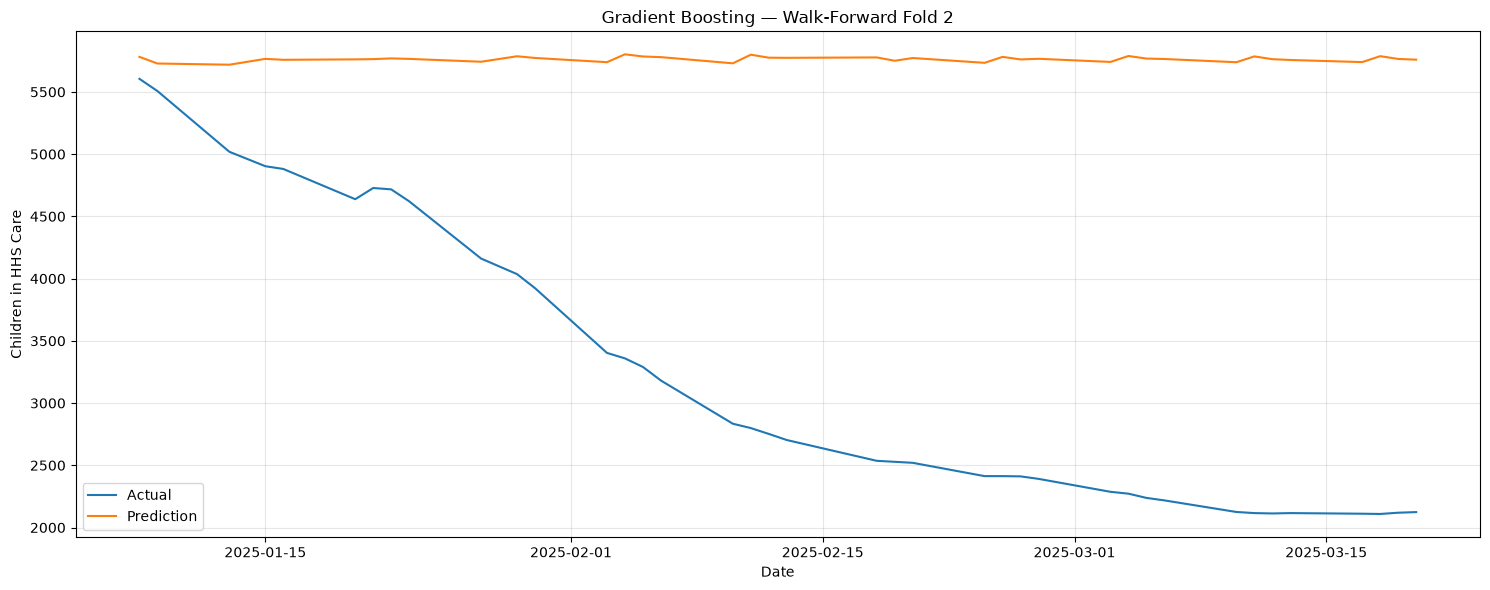

In [170]:
plt.figure(figsize=(15, 6))

plt.plot(
    fold_2["Date"],
    fold_2[target],
    label="Actual"
)

plt.plot(
    fold_2["Date"],
    fold_2["Prediction"],
    label="Prediction"
)

plt.title(
    "Gradient Boosting — Walk-Forward Fold 2"
)

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [171]:
fold_2[[target]].describe()

,Children in HHS Care
count,39.000000
mean,3185.128205
std,1131.639360
min,2109.000000
25%,2255.000000
50%,2703.000000
75%,4098.500000
max,5605.000000


In [172]:
print(
    fold_2.loc[
        fold_2["Absolute_Error"].nlargest(10).index
    ]
)

         Date  Children in HHS Care   Prediction        Error  Absolute_Error  \
75 2025-03-18                  2109  5787.248893 -3678.248893     3678.248893   
71 2025-03-11                  2116  5785.350972 -3669.350972     3669.350972   
72 2025-03-12                  2113  5762.958701 -3649.958701     3649.958701   
76 2025-03-19                  2119  5764.856621 -3645.856621     3645.856621   
73 2025-03-13                  2116  5756.539627 -3640.539627     3640.539627   
77 2025-03-20                  2124  5759.115794 -3635.115794     3635.115794   
74 2025-03-17                  2111  5739.538659 -3628.538659     3628.538659   
70 2025-03-10                  2125  5738.455557 -3613.455557     3613.455557   
69 2025-03-06                  2218  5764.386922 -3546.386922     3546.386922   
68 2025-03-05                  2238  5767.937160 -3529.937160     3529.937160   

    Fold  
75     2  
71     2  
72     2  
76     2  
73     2  
77     2  
74     2  
70     2  
69     2 

In [173]:
fold_2_dates = fold_2["Date"]

fold_2_features = forecast_df[
    forecast_df["Date"].isin(fold_2_dates)
].copy()

fold_2_full = fold_2_features.merge(
    fold_2[
        [
            "Date",
            "Prediction",
            "Error",
            "Absolute_Error"
        ]
    ],
    on="Date",
    how="inner"
)

print("Fold 2 complete shape:", fold_2_full.shape)

fold_2_full.head()

Fold 2 complete shape: (39, 26)


,Date,Children in HHS Care,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,hhs_lag_1,...,discharge_lag_1,discharge_lag_7,discharge_lag_14,hhs_rolling_mean_7d,hhs_rolling_mean_14d,hhs_rolling_std_7d,hhs_rolling_std_14d,Prediction,Error,Absolute_Error
0,2025-01-08,5605,2,8,1,1,2025,2,0,5703.0,...,133.0,144.0,107.0,5850.2,6142.444444,266.731513,403.172454,5781.402301,-176.402301,176.402301
1,2025-01-09,5507,3,9,1,1,2025,2,0,5605.0,...,184.0,170.0,135.0,5693.2,6009.111111,144.859242,391.383905,5728.245203,-221.245203,221.245203
2,2025-01-13,5019,0,13,1,1,2025,3,0,5092.0,...,235.0,190.0,177.0,5385.2,5697.111111,309.924507,469.708272,5718.580498,-699.580498,699.580498
3,2025-01-15,4903,2,15,1,1,2025,3,0,4957.0,...,139.0,184.0,144.0,5095.6,5472.900000,240.538562,464.228260,5765.493711,-862.493711,862.493711
4,2025-01-16,4881,3,16,1,1,2025,3,0,4903.0,...,164.0,164.0,170.0,4970.4,5331.800000,86.404861,397.198467,5758.026474,-877.026474,877.026474


In [174]:
cols_to_check = [
    "Date",
    target,
    "hhs_lag_1",
    "hhs_lag_7",
    "hhs_lag_14",
    "hhs_lag_28",
    "hhs_rolling_mean_7d",
    "hhs_rolling_mean_14d"
]

In [175]:
fold_2_full[
    [
        "Date",
        "Children in HHS Care",
        "Prediction",
        "Error",
        "Absolute_Error"
    ]
].sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Date,Children in HHS Care,Prediction,Error,Absolute_Error
36,2025-03-18,2109,5787.248893,-3678.248893,3678.248893
32,2025-03-11,2116,5785.350972,-3669.350972,3669.350972
33,2025-03-12,2113,5762.958701,-3649.958701,3649.958701
37,2025-03-19,2119,5764.856621,-3645.856621,3645.856621
34,2025-03-13,2116,5756.539627,-3640.539627,3640.539627
38,2025-03-20,2124,5759.115794,-3635.115794,3635.115794
35,2025-03-17,2111,5739.538659,-3628.538659,3628.538659
31,2025-03-10,2125,5738.455557,-3613.455557,3613.455557
30,2025-03-06,2218,5764.386922,-3546.386922,3546.386922
29,2025-03-05,2238,5767.937160,-3529.937160,3529.937160


In [176]:
fold_2_full[cols_to_check].head(20)

,Date,Children in HHS Care,hhs_lag_1,hhs_lag_7,hhs_lag_14,hhs_lag_28,hhs_rolling_mean_7d,hhs_rolling_mean_14d
0,2025-01-08,5605,5703.0,6405.0,6689.0,6402.0,5850.2,6142.444444
1,2025-01-09,5507,5605.0,6292.0,6707.0,6481.0,5693.2,6009.111111
2,2025-01-13,5019,5092.0,5769.0,6454.0,6454.0,5385.2,5697.111111
3,2025-01-15,4903,4957.0,5605.0,6405.0,6598.0,5095.6,5472.900000
4,2025-01-16,4881,4903.0,5507.0,6292.0,6600.0,4970.4,5331.800000
5,2025-01-20,4638,4628.0,5019.0,5769.0,6548.0,4801.4,5093.300000
6,2025-01-21,4728,4638.0,4957.0,5703.0,6622.0,4755.6,4995.800000
7,2025-01-22,4717,4728.0,4903.0,5605.0,6689.0,4718.4,4907.000000
8,2025-01-23,4621,4717.0,4881.0,5507.0,6707.0,4666.4,4818.400000
9,2025-01-27,4161,4241.0,4638.0,5019.0,6454.0,4493.6,4647.500000


In [177]:
print(fold_2_full.columns.tolist())

['Date', 'Children in HHS Care', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'hhs_lag_1', 'hhs_lag_7', 'hhs_lag_14', 'hhs_lag_28', 'transfer_lag_1', 'transfer_lag_7', 'transfer_lag_14', 'discharge_lag_1', 'discharge_lag_7', 'discharge_lag_14', 'hhs_rolling_mean_7d', 'hhs_rolling_mean_14d', 'hhs_rolling_std_7d', 'hhs_rolling_std_14d', 'Prediction', 'Error', 'Absolute_Error']


In [178]:
fold_2_full[
    ["Date"] + forecast_features
].describe()

,Date,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,hhs_lag_1,hhs_lag_7,...,transfer_lag_1,transfer_lag_7,transfer_lag_14,discharge_lag_1,discharge_lag_7,discharge_lag_14,hhs_rolling_mean_7d,hhs_rolling_mean_14d,hhs_rolling_std_7d,hhs_rolling_std_14d
count,39,39.000000,39.000000,39.000000,39.0,39.0,39.000000,39.0,39.000000,39.000000,...,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2025-02-14 07:23:04.615384,1.615385,15.230769,2.000000,1.0,2025.0,7.384615,0.0,3216.384615,3544.769231,...,34.461538,40.076923,54.205128,71.487179,85.769231,95.282051,3299.079487,3488.564672,118.185904,242.023033
min,2025-01-08 00:00:00,0.000000,3.000000,1.000000,1.0,2025.0,2.000000,0.0,2109.000000,2113.000000,...,0.000000,1.000000,1.000000,5.000000,6.000000,9.000000,2113.200000,2118.700000,2.509980,8.206366
25%,2025-01-28 00:00:00,1.000000,9.500000,1.000000,1.0,2025.0,5.000000,0.0,2279.500000,2412.000000,...,8.000000,11.000000,15.000000,23.000000,24.500000,35.000000,2314.300000,2381.000000,49.452368,91.933559
50%,2025-02-13 00:00:00,2.000000,15.000000,2.000000,1.0,2025.0,7.000000,0.0,2752.000000,3181.000000,...,15.000000,23.000000,36.000000,50.000000,74.000000,99.000000,2793.200000,3068.200000,85.562355,258.698398
75%,2025-03-04 12:00:00,3.000000,20.500000,3.000000,1.0,2025.0,10.000000,0.0,4168.500000,4677.500000,...,40.000000,60.500000,88.000000,103.000000,144.500000,152.000000,4362.300000,4561.100000,196.583777,394.291186
max,2025-03-20 00:00:00,3.000000,30.000000,3.000000,1.0,2025.0,12.000000,0.0,5703.000000,6405.000000,...,168.000000,136.000000,193.000000,235.000000,190.000000,190.000000,5850.200000,6142.444444,322.429372,475.463750
std,NaN,1.138221,7.908894,0.794719,0.0,0.0,3.091715,0.0,1150.365768,1334.097457,...,41.248187,38.447767,49.489063,62.618675,62.461130,59.803603,1191.466903,1282.073842,99.584063,156.698729


In [179]:
train_before_fold2 = forecast_df.iloc[:343].copy()

comparison = pd.DataFrame({
    "Training_Mean": train_before_fold2[forecast_features].mean(),
    "Fold2_Mean": fold_2_full[forecast_features].mean(),
    "Training_Max": train_before_fold2[forecast_features].max(),
    "Fold2_Max": fold_2_full[forecast_features].max()
})

comparison

,Training_Mean,Fold2_Mean,Training_Max,Fold2_Max
day_of_week,1.556851,1.615385,3.000000,3.000000
day_of_month,15.880466,15.230769,31.000000,30.000000
month,6.510204,2.000000,12.000000,3.000000
quarter,2.504373,1.000000,4.000000,1.000000
year,2023.609329,2025.000000,2025.000000,2025.000000
week_of_year,26.586006,7.384615,52.000000,12.000000
is_weekend,0.000000,0.000000,0.000000,0.000000
hhs_lag_1,7695.574344,3216.384615,11516.000000,5703.000000
hhs_lag_7,7781.099125,3544.769231,11516.000000,6405.000000
hhs_lag_14,7824.020408,3962.333333,11516.000000,6707.000000


In [181]:
model_df = df.copy()

model_df["Date"] = pd.to_datetime(
    model_df["Date"]
)

model_df = model_df.sort_values(
    "Date"
).reset_index(drop=True)

NameError: name 'df' is not defined

In [ ]:
df_daily = (
    df_model
    .set_index("Date")
    .sort_index()
)

In [ ]:
date_differences = (
    df_daily.index.to_series()
    .diff()
    .dt.days
)

print(
    date_differences.value_counts()
    .sort_index()
)

In [182]:
print("df" in globals())
print("model_df" in globals())
print("forecast_df" in globals())

False
True
True


In [183]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\notebooks
['03_modeling.ipynb', 'EDA.ipynb', 'Feature_Engineering.ipynb', 'Modeling.ipynb', 'outputs']


In [184]:
print(os.listdir("data"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data'